# Urine Data Analysis

With the cleaned and individually exported data, now the data is ready to be fine tuned and analysed. Urine data will be first analyzed before moving onto the blood lab analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
current_directory = os.getcwd()
print(current_directory)

C:\Users\Rachel\Documents\Github\portfolio_ds_projects\NHANES_analysis


In [3]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_cr = pd.read_csv('urine_cr_alb.csv')

In [4]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [5]:
df_d.isna().sum()

participant_id              0
gender                      0
age_year                    0
race                        0
education_level          5756
marital_status           5756
family_income_poverty    1847
dtype: int64

In [6]:
df_d.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,14300.000000,14300.000000,14300.000000,14300.000000,8544.000000,8544.000000,12453.000000
mean,117068.670280,1.504545,33.861818,3.482797,3.554775,1.694640,2.385320
std,4501.643618,0.499997,25.162121,1.625440,1.210994,2.613598,1.625954
min,109263.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,113170.750000,1.000000,10.000000,3.000000,3.000000,1.000000,1.010000
50%,117081.500000,2.000000,31.000000,3.000000,4.000000,1.000000,1.940000
75%,120974.250000,2.000000,56.000000,4.000000,4.000000,2.000000,3.850000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


Current data analysis will focus on adults aged 18 or older. Subjects that are younger than 18 will be removed.

In [7]:
adults = df_d[df_d['age_year'] >= 18]

In [8]:
adults.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,8965.000000,8965.000000,8965.000000,8965.000000,8544.000000,8544.000000,7705.000000
mean,117107.849637,1.513999,49.465142,3.484551,3.554775,1.694640,2.558740
std,4501.048325,0.499832,18.457564,1.574461,1.210994,2.613598,1.627623
min,109266.000000,1.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,113211.000000,1.000000,33.000000,3.000000,3.000000,1.000000,1.170000
50%,117091.000000,2.000000,50.000000,3.000000,4.000000,1.000000,2.160000
75%,121022.000000,2.000000,64.000000,4.000000,4.000000,2.000000,4.140000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


The next is anthropometry (body measures). First, the question is how much of the documented samples is considered obese. The BMI cutoffs are as follows:
 * less than 18 kg/m^2: underweight
 * 18-24.9 kg/m^2: normal weight
 * 25-29.9 kg/m^2: overweight
 * 30-39.9 kg/m^2: obese
 * greater than 40 kg/m^2: morbidly obese


In [9]:
df_a.isna().sum()

participant_id                 0
weight_kg                     32
weight_comment             13519
recumbent_length_cm        12637
standing_height              950
standing_height_comment    13936
bmi                          970
bmi_category_child          9358
upper_leg_cm                3123
upper_arm_cm                 617
arm_circumference_cm         623
waist_circ_cm               1533
hip_circ_cm                 4245
dtype: int64

Since this data analysis focuses on evaluating BMI, the subjects that are missing the BMI should be dropped. By joining the adults data frame with the anthropometry (in the next steps to come), subjects under the age 18 will automatically be removed. 

In [10]:
df_a = df_a.dropna(subset=['bmi'])

In [11]:
df_a.isna().sum()

participant_id                 0
weight_kg                      0
weight_comment             12601
recumbent_length_cm        12571
standing_height                0
standing_height_comment    13038
bmi                            0
bmi_category_child          8388
upper_leg_cm                2177
upper_arm_cm                 460
arm_circumference_cm         461
waist_circ_cm                603
hip_circ_cm                 3296
dtype: int64

Columns that are more pertinent to pediatric population (recumbent length, BMI child category) will be dropped.

Some of the subjects are wearing clothes or have medical appliances when they are getting their weight measured. However, clothing generally only tends to add up to about 5 lbs and the weight of medical appliances that generally are on the persons are typically negligible so the decision was made to drop the weight comment column. 

In [12]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [13]:
df_a = df_a.drop(['recumbent_length_cm','bmi_category_child','weight_comment'], axis = 1)

In [14]:
adults_joined = adults.merge(df_a, on='participant_id')

Before making the decision for various statistical analyses, the data will first be explored for basic information. 

What is the percentage of the subjects that are obese?
What is the mean BMI? Median?

In [15]:
adults_joined['bmi'].describe()

count    8790.000000
mean       29.883413
std         7.603916
min        14.200000
25%        24.700000
50%        28.600000
75%        33.600000
max        92.300000
Name: bmi, dtype: float64

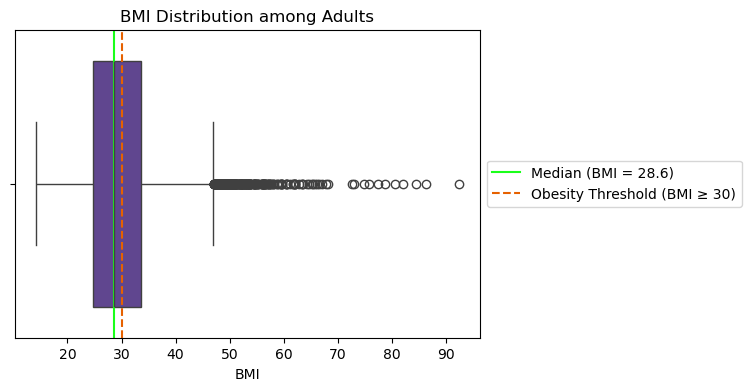

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B')

# Calculate median
median_val = adults_joined['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

As we can see, even at average, the weight distribution among adults doesn't fall into normal weight. In fact, the mean weight of this dataset, which is supposed to mimic the American population, is in the upper range of overweight bordering obesity. The weight of the Americans are overall increased.

However, there are significant outliers with values such as 92.3 which would increase average. To address the outlier, the decision was made to see how many subjects have BMI greater than 60.

In [17]:
num_high_bmi = (adults_joined['bmi'] >= 60).sum()
print(f"Number of subjects with BMI >= 60: {num_high_bmi}")
prop_high_bmi = (adults_joined['bmi'] >= 60).mean()
print(f"Proportion of subjects with BMI >= 60: {prop_high_bmi:.2%}")

Number of subjects with BMI >= 60: 36
Proportion of subjects with BMI >= 60: 0.41%


Out of the number of obese subjects, there are less than 1% of the dataset which have BMI equal to or greater thn 60. BMI of 60 is also not frequently encountered. Further elimination may be warranted. 

The decision was made to see how many subjects have BMI falling between 50 and 60.

In [18]:
# Count number of subjects with 50 <= BMI < 60
num_bmi_50_60 = ((adults_joined['bmi'] >= 50) & (adults_joined['bmi'] < 60)).sum()
print(f"Number of subjects with BMI between 50 and 60: {num_bmi_50_60}")
prop_bmi_50_60 = ((adults_joined['bmi'] >= 50) & (adults_joined['bmi'] < 60)).mean()
print(f"Proportion of subjects with BMI between 50 and 60: {prop_bmi_50_60:.2%}")

Number of subjects with BMI between 50 and 60: 135
Proportion of subjects with BMI between 50 and 60: 1.54%


Combining both of these values, the total proportion of adult subjects with BMI falling above 50 is 1.94%. The decision was made to drop those subjects whose BMI is greater than 50.

In [19]:
adults_filtered = adults_joined[adults_joined['bmi'] <= 50].copy()

In [20]:
adults_filtered['bmi'].describe()

count    8622.000000
mean       29.357237
std         6.583851
min        14.200000
25%        24.600000
50%        28.500000
75%        33.300000
max        50.000000
Name: bmi, dtype: float64

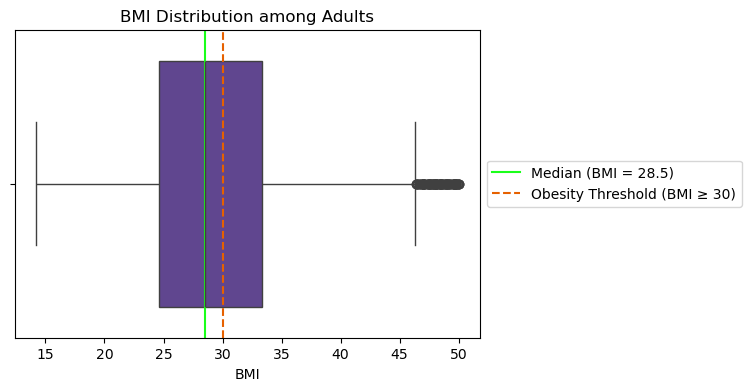

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_filtered, color = '#5D3A9B')

# Calculate median
median_val = adults_filtered['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

As we can see, even with the outliers removed, the average weight of the subjects in this dataset still falls in the overweight range. The overall weight has increased in the American population.

Next step is to create a data frame with subjects that are obese by the BMI value.

In [22]:
obese = adults_filtered[adults_filtered['bmi'] >= 30]

In [23]:
obese.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.0,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1
3,109274.0,1.0,68.0,7.0,4.0,3.0,1.2,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8
5,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,39.1,33.0,33.5,38.5,103.1,125.5
8,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,31.3,NaN,NaN,NaN,NaN,NaN
9,109292.0,1.0,58.0,2.0,3.0,2.0,1.6,86.0,167.8,NaN,30.5,38.4,39.5,29.0,108.3,106.4


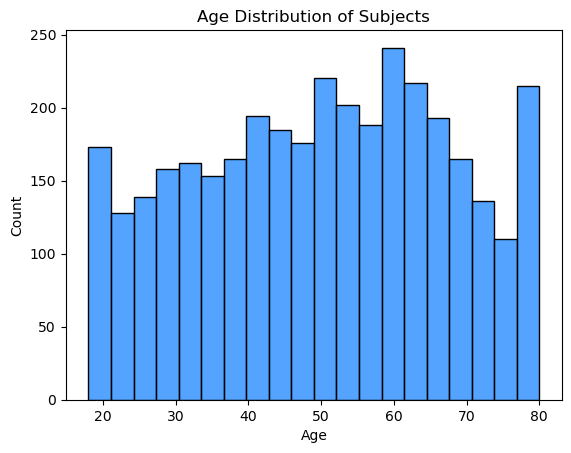

In [24]:
sns.histplot(x='age_year', bins = 20, data=obese, color = '#1A85FF')
plt.title('Age Distribution of Subjects')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The age distribution histogram seems to show that the general trend seems to be that as people age from their early 20s to early 60s, the obesity trend seems to peak and decrease until they get to late 70s. However, the trend appears to be quite weak. 

## Urine Albumin and Creatinine

The first urine lab value that will be analyzed against the BMI is the urine creatinine and albumin. Both of these tests are conducted as spot test, not as total excretion over 24 hours. 


According to the laboratory test that was performed for the purposes of NHANES, the normal range for urine creatinine is as reported as follows:

 * Urine, adult male, first morning void: 40-278 mg/dL
 * Urine, adult female, first morning void: 29-226 mg/dL

(Mazzachi, et al. From the Roche reagent package insert for enzymatic creatinine.)

Spot testing of urine albumin should be <21 mcg/mL. For the assay conducted by NHANES lab, the unusual albumin values designated “< LOD” or > 1000 µg/mL are flagged for
attention.

To make the analysis and evaluation clearer, only the columns reflecting these units will be kept.

In [25]:
df_cralb = pd.read_csv('urine_cr_alb.csv')

In [26]:
urine_cralb = obese.merge(df_cralb, on='participant_id')

In [27]:
urine_cralb.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,...,hip_circ_cm,Unnamed: 0,albumin_urine_ug_mL,albumin_urine_mg_L,alb_comment,creatinine_urine_mg_dL,creatinine_urine_umol_L,creatinine_comment,alb_creat_ratio,collection_year
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,...,126.1,1,5.5,5.5,0.0,36.0,3182.4,0.0,15.28,2017-2020
1,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,...,107.8,5,12.8,12.8,0.0,120.0,10608.0,0.0,10.67,2017-2020
2,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,...,125.5,11,8.2,8.2,0.0,189.0,16707.6,0.0,4.34,2017-2020
3,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,...,NaN,17,16.4,16.4,0.0,261.0,23072.4,0.0,6.28,2017-2020
4,109293.0,1.0,44.0,3.0,3.0,3.0,0.02,99.4,181.6,NaN,...,120.2,19,7.2,7.2,0.0,57.0,5038.8,0.0,12.63,2017-2020


In [28]:
urine_cralb.shape

(3448, 25)

In [29]:
urine_cralb.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'standing_height', 'standing_height_comment', 'bmi', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'Unnamed: 0', 'albumin_urine_ug_mL', 'albumin_urine_mg_L',
       'alb_comment', 'creatinine_urine_mg_dL', 'creatinine_urine_umol_L',
       'creatinine_comment', 'alb_creat_ratio', 'collection_year'],
      dtype='object')

In [32]:
urine_cralb = urine_cralb[['participant_id','gender','age_year','race','bmi',
'albumin_urine_ug_mL', 'creatinine_urine_mg_dL','alb_creat_ratio']]

In [33]:
urine_cralb.isna().sum()

participant_id            0
gender                    0
age_year                  0
race                      0
bmi                       0
albumin_urine_ug_mL       0
creatinine_urine_mg_dL    0
alb_creat_ratio           0
dtype: int64

With the initial data cleaning, the NaN values have been removed. 

In [34]:
urine_cralb.describe()

,participant_id,gender,age_year,race,bmi,albumin_urine_ug_mL,creatinine_urine_mg_dL,alb_creat_ratio
count,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000
mean,117062.047564,1.545244,49.816995,3.266531,35.782570,63.937558,142.477378,57.838222
std,4564.177792,0.498021,17.155913,1.471719,4.709608,405.712906,88.483911,371.666530
min,109266.000000,1.000000,18.000000,1.000000,30.000000,0.300000,8.000000,0.860000
25%,113031.000000,1.000000,36.000000,3.000000,32.000000,5.500000,76.000000,4.960000
50%,116966.500000,2.000000,51.000000,3.000000,34.600000,10.600000,126.500000,7.880000
75%,121099.500000,2.000000,63.000000,4.000000,38.500000,22.800000,190.000000,16.122500
max,124818.000000,2.000000,80.000000,7.000000,50.000000,14040.000000,609.000000,11055.120000


In [37]:
urine_alb = urine_cralb[['participant_id','gender','age_year','bmi','albumin_urine_ug_mL']]

In [38]:
urine_alb['albumin_urine_ug_mL'].describe()

count     3448.000000
mean        63.937558
std        405.712906
min          0.300000
25%          5.500000
50%         10.600000
75%         22.800000
max      14040.000000
Name: albumin_urine_ug_mL, dtype: float64

Although the range of the urine albumin can be a bit ambiguous, values that are significantly above 1000 mcg/mL seems to be too extreme. The data was visualized to see how the distribution appears.

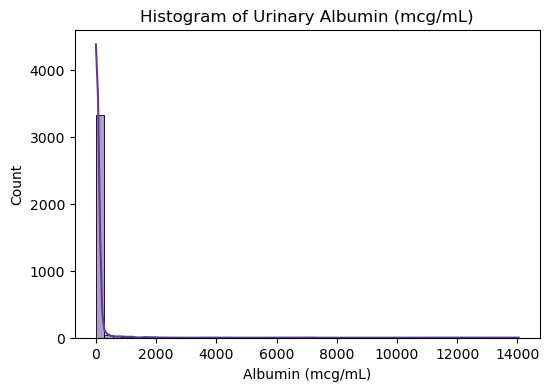

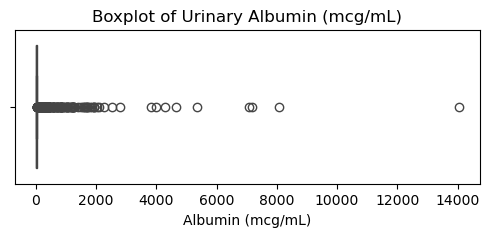

In [39]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(urine_alb['albumin_urine_ug_mL'], bins=50, kde=True, color='#5D3A9B')
plt.title("Histogram of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

Because the urine albumin range can be a bit arbitrary, dropping of outliers may not be the best route. However, the 14,000 value should be removed since that is unlikely that the urine albumin level would be that high in the clinical setting. 

The question that arises with this level of albumin is, what is the health status of these subjects? Are they higher in the BMI range than other subjects that have more "reasonable" albumin range? 

In [40]:
urine_alb = urine_alb[urine_alb['albumin_urine_ug_mL'] != 14040]

In [41]:
urine_alb['albumin_flag'] = urine_alb['albumin_urine_ug_mL'].apply(lambda x: 'High' if x >= 1000 else 'Normal')

C:\Users\Rachel\AppData\Local\Temp\ipykernel_14500\4157928887.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='albumin_flag', y='albumin_urine_ug_mL', data=urine_alb, palette=['#5D3A9B','#E66100'])


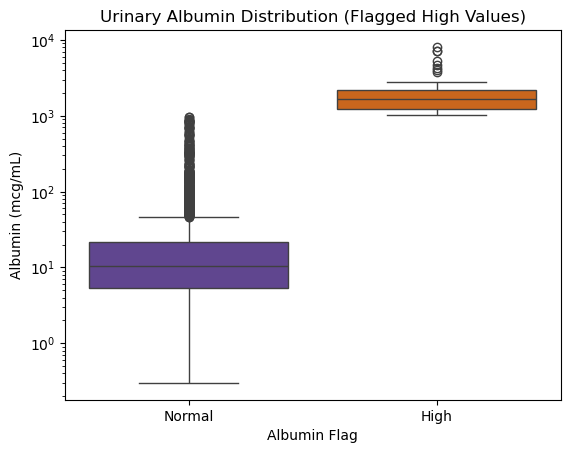

In [43]:
sns.boxplot(x='albumin_flag', y='albumin_urine_ug_mL', data=urine_alb, palette=['#5D3A9B','#E66100'])
plt.yscale('log')  # Optional: log-scale to better show distribution
plt.title("Urinary Albumin Distribution (Flagged High Values)")
plt.xlabel('Albumin Flag')
plt.ylabel('Albumin (mcg/mL)')
plt.show()

In [44]:
# Define your threshold
threshold = 1000  

# Count how many subjects exceed the threshold
extreme_count = (urine_alb['albumin_urine_ug_mL'] >= threshold).sum()

# Total number of subjects
total_count = urine_alb['albumin_urine_ug_mL'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme albumin values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with albumin values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")


Subjects with extreme albumin values (≥ 1000 µg/mL): 43
Total subjects with albumin values: 3447
Percentage extreme: 1.25%


Although the albumin values are not inherently critical at an elevated level, values above 1000 mcg/mL are highly unusual. As we can see, only 1.25% (43 out of 3447) of the subjects have this extreme value above 1000 mcg/mL. The decision was made to remove these subjects to have a more representative dataset for analysis. 

In [47]:
# Define threshold
threshold = 1000  

# Keep only subjects below threshold
urine_alb_clean = urine_alb[urine_alb['albumin_urine_ug_mL'] < threshold].copy()

print(f"Original: {urine_alb.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_alb_clean.shape[0]} rows")


Original: 3447 rows
After removing extreme albumin values: 3404 rows


In [48]:
extreme_subjects = urine_alb[urine_cralb['albumin_urine_ug_mL'] >= threshold]

C:\Users\Rachel\AppData\Local\Temp\ipykernel_14500\3687547731.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  extreme_subjects = urine_alb[urine_cralb['albumin_urine_ug_mL'] >= threshold]


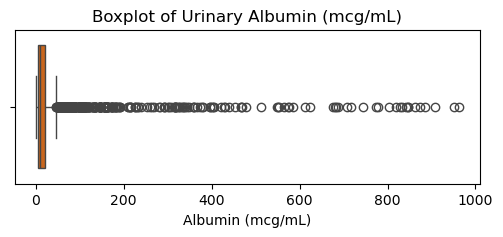

In [49]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb_clean['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

In [50]:
urine_alb_clean.describe()

,participant_id,gender,age_year,bmi,albumin_urine_ug_mL
count,3404.000000,3404.000000,3404.000000,3404.000000,3404.000000
mean,117071.677732,1.546710,49.774677,35.767039,31.734929
std,4560.132234,0.497887,17.187512,4.710558,85.467464
min,109266.000000,1.000000,18.000000,30.000000,0.300000
25%,113050.500000,1.000000,36.000000,32.000000,5.400000
50%,116979.500000,2.000000,50.000000,34.600000,10.400000
75%,121101.750000,2.000000,63.000000,38.500000,21.825000
max,124818.000000,2.000000,80.000000,50.000000,962.000000
